# Tugas Besar Machine Learning
## Klasifikasi Jenis Game Steam Berdasarkan Metadata

**Dataset:** `games_all.csv` (hasil scraping Steam Store — 1130 game, 13 kolom)

**Jenis tugas:** Supervised Learning — **Klasifikasi Multi-Kelas**

**Target:** Jenis game berdasarkan mode pemain — diturunkan dari kolom `Number Of Players`:
- **Singleplayer** — game khusus solo
- **Multiplayer** — game khusus multipemain (PvP/Co-op/Online)
- **Hybrid** — game yang punya mode singleplayer DAN multiplayer

---
### Alur (sesuai ketentuan tugas)
1. Load & eksplorasi dataset
2. **EDA** — 35+ insight + penjelasan
3. **Cleaning, feature engineering, standarisasi, feature selection** (+ alasan)
4. **Penanganan imbalance** target (SMOTE) — kelas Multiplayer minoritas
5. **Membangun & membandingkan** 5 model klasifikasi
6. **Tuning** model terbaik (GridSearchCV)
7. **Evaluasi** + cek overfitting/underfitting
8. **Export** model untuk deployment Streamlit


## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)
print('Library siap.')

Library siap.


## 1. Load Dataset & Sekilas Data

In [2]:
df = pd.read_csv('games_all.csv')
print('Bentuk data (baris, kolom):', df.shape)
df.head()

Bentuk data (baris, kolom): (1130, 13)


,AppID,Name,Published Date,Original Price,Discount Price,Discount %,Reviews Count,Reviews Positive,Review Label,Search Filter,Number Of Players,Controller Support,OS
0,730,Counter-Strike 2,"21 Aug, 2012",Free,Free,NaN,2556344.0,86%,Very Positive,"mostplayed, newreleases, topsellers, upcomingr...","Cross-Platform Multiplayer, Multi-player",NaN,"SteamOS + Linux, Windows"
1,4704690,MECCHA CHAMELEON,"9 Jun, 2026",Rp 58 499,Rp 46 799,-20%,2587.0,80%,Very Positive,"mostplayed, newreleases, topsellers, upcomingr...","Multi-player, Online PvP, PvP",NaN,Windows
2,1085660,Destiny 2,"1 Oct, 2019",Free,Free,NaN,384732.0,78%,Mostly Positive,"mostplayed, newreleases, topsellers, upcomingr...","Co-op, Multi-player, Online Co-op, Online PvP,...","DualShock Controller Support, Dualsense Contro...",Windows
3,2483190,Forza Horizon 6,"18 May, 2026",Rp 899 000,Rp 899 000,NaN,33155.0,86%,Very Positive,"mostplayed, newreleases, topsellers, upcomingr...","Co-op, Multi-player, Online Co-op, Online PvP,...","Full Controller Support, Gamepad Preferred, Xb...",Windows
4,3405690,EA SPORTS FC™ 26,"25 Sep, 2025",Rp 239 000,Rp 47 800,-80%,20122.0,47%,Mixed,"mostplayed, newreleases, topsellers, upcomingr...","Co-op, Cross-Platform Multiplayer, Multi-playe...","DualShock Controller Support, Dualsense Contro...",Windows


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1130 entries, 0 to 1129
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AppID               1130 non-null   int64  
 1   Name                1130 non-null   str    
 2   Published Date      1130 non-null   str    
 3   Original Price      1124 non-null   str    
 4   Discount Price      1124 non-null   str    
 5   Discount %          418 non-null    str    
 6   Reviews Count       1093 non-null   float64
 7   Reviews Positive    1093 non-null   str    
 8   Review Label        1093 non-null   str    
 9   Search Filter       1130 non-null   str    
 10  Number Of Players   1116 non-null   str    
 11  Controller Support  860 non-null    str    
 12  OS                  1124 non-null   str    
dtypes: float64(1), int64(1), str(11)
memory usage: 114.9 KB


In [4]:
# Cek nilai kosong
df.isnull().sum()

AppID                   0
Name                    0
Published Date          0
Original Price          6
Discount Price          6
Discount %            712
Reviews Count          37
Reviews Positive       37
Review Label           37
Search Filter           0
Number Of Players      14
Controller Support    270
OS                      6
dtype: int64

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AppID,1130.0,NaN,NaN,NaN,1981771.559292,1257727.942858,440.0,946327.5,1875230.0,2956672.5,4764930.0
Name,1130,1130,Counter-Strike 2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Published Date,1130,784,"11 Jun, 2026",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Original Price,1124,364,Free,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discount Price,1124,548,Free,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discount %,418,46,-50%,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviews Count,1093.0,NaN,NaN,NaN,34151.225069,107729.939513,10.0,1734.0,7293.0,27013.0,2556344.0
Reviews Positive,1093,75,95%,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Label,1093,7,Very Positive,562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Search Filter,1130,7,"mostplayed, newreleases, topsellers, upcomingr...",811,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis (EDA) — 35+ Insight

Sebelum membangun fitur, beberapa kolom masih berupa teks (mis. `Rp 650 000`, `-10%`, `26 May, 2026`,
`Co-op, Multi-player, Singleplayer`). Kita parse versi numeriknya **khusus untuk EDA** agar
bisa dianalisis. Cleaning final akan dilakukan di Bagian 3.

In [6]:
eda = df.copy()

def parse_price(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    if x.lower() == 'free': return 0.0
    digits = ''.join(c for c in x if c.isdigit())
    return float(digits) if digits else np.nan

eda['orig_price'] = eda['Original Price'].apply(parse_price)
eda['disc_price'] = eda['Discount Price'].apply(parse_price)
eda['disc_pct']   = eda['Discount %'].replace('N/A', np.nan).str.replace('%','').str.replace('-','').astype(float)
eda['rev_pos']    = eda['Reviews Positive'].str.replace('%','').astype(float)
eda['pub_date']   = pd.to_datetime(eda['Published Date'], format='%d %b, %Y', errors='coerce')
eda['year']       = eda['pub_date'].dt.year
SNAPSHOT = pd.Timestamp('2026-06-15')
eda['age_years']  = (SNAPSHOT - eda['pub_date']).dt.days / 365

# derive target (jenis game)
def classify_type(s):
    if pd.isna(s): return None
    s = str(s)
    has_single = 'Singleplayer' in s
    has_multi  = any(k in s for k in ['Multi-player', 'PvP', 'Co-op'])
    if has_single and has_multi: return 'Hybrid'
    if has_single: return 'Singleplayer'
    if has_multi:  return 'Multiplayer'
    return None
eda['game_type'] = eda['Number Of Players'].apply(classify_type)
eda.head(3)

,AppID,Name,Published Date,Original Price,Discount Price,Discount %,Reviews Count,Reviews Positive,Review Label,Search Filter,...,Controller Support,OS,orig_price,disc_price,disc_pct,rev_pos,pub_date,year,age_years,game_type
0,730,Counter-Strike 2,"21 Aug, 2012",Free,Free,NaN,2556344.0,86%,Very Positive,"mostplayed, newreleases, topsellers, upcomingr...",...,NaN,"SteamOS + Linux, Windows",0.0,0.0,NaN,86.0,2012-08-21,2012,13.824658,Multiplayer
1,4704690,MECCHA CHAMELEON,"9 Jun, 2026",Rp 58 499,Rp 46 799,-20%,2587.0,80%,Very Positive,"mostplayed, newreleases, topsellers, upcomingr...",...,NaN,Windows,58499.0,46799.0,20.0,80.0,2026-06-09,2026,0.016438,Multiplayer
2,1085660,Destiny 2,"1 Oct, 2019",Free,Free,NaN,384732.0,78%,Mostly Positive,"mostplayed, newreleases, topsellers, upcomingr...",...,"DualShock Controller Support, Dualsense Contro...",Windows,0.0,0.0,NaN,78.0,2019-10-01,2019,6.709589,Hybrid


### 2.1 Statistik ringkas (dasar insight 1–15)

In [7]:
print('Jumlah baris / kolom         :', eda.shape)
print('AppID unik                   :', eda['AppID'].nunique())
print('Nama game unik               :', eda['Name'].nunique(), ' (= jumlah baris, jadi TIDAK ADA DUPLIKASI)')
print('Game gratis (Free)           :', (eda['orig_price']==0).sum(), f"({(eda['orig_price']==0).mean()*100:.1f}%)")
print('Harga rata-rata (berbayar)   : Rp', f"{eda.loc[eda.orig_price>0,'orig_price'].mean():,.0f}")
print('Harga median (berbayar)      : Rp', f"{eda.loc[eda.orig_price>0,'orig_price'].median():,.0f}")
print('Harga termahal               : Rp', f"{eda['orig_price'].max():,.0f}", '-', eda.loc[eda.orig_price.idxmax(),'Name'])
print('Game sedang diskon           :', (eda['disc_pct']>0).sum(), f"({(eda['disc_pct']>0).mean()*100:.1f}%)")
print('Rata-rata diskon (yg diskon) :', f"{eda.loc[eda.disc_pct>0,'disc_pct'].mean():.1f}%")
print('Diskon maksimum              :', f"{eda['disc_pct'].max():.0f}%")
print('Reviews Count median / mean  :', f"{eda['Reviews Count'].median():,.0f}", '/', f"{eda['Reviews Count'].mean():,.0f}")
print('Paling banyak direview       :', eda.loc[eda['Reviews Count'].idxmax(),'Name'])
print('% positif rata-rata          :', f"{eda['rev_pos'].mean():.1f}%")
print('Rentang tahun rilis          :', int(eda['year'].min()), '-', int(eda['year'].max()))
print('Game belum rilis (future)    :', (eda['pub_date']>SNAPSHOT).sum())

Jumlah baris / kolom         : (1130, 21)
AppID unik                   : 1130
Nama game unik               : 1130  (= jumlah baris, jadi TIDAK ADA DUPLIKASI)
Game gratis (Free)           : 120 (10.6%)
Harga rata-rata (berbayar)   : Rp 316,087
Harga median (berbayar)      : Rp 239,000
Harga termahal               : Rp 1,149,000 - LEGO® Batman™: Legacy of the Dark Knight
Game sedang diskon           : 418 (37.0%)
Rata-rata diskon (yg diskon) : 50.3%
Diskon maksimum              : 95%
Reviews Count median / mean  : 7,293 / 34,151
Paling banyak direview       : Counter-Strike 2
% positif rata-rata          : 81.9%
Rentang tahun rilis          : 2006 - 2027
Game belum rilis (future)    : 29


### 2.2 Distribusi Target — Jenis Game

game_type
Hybrid          541
Singleplayer    456
Multiplayer     119
NaN              14
Name: count, dtype: int64


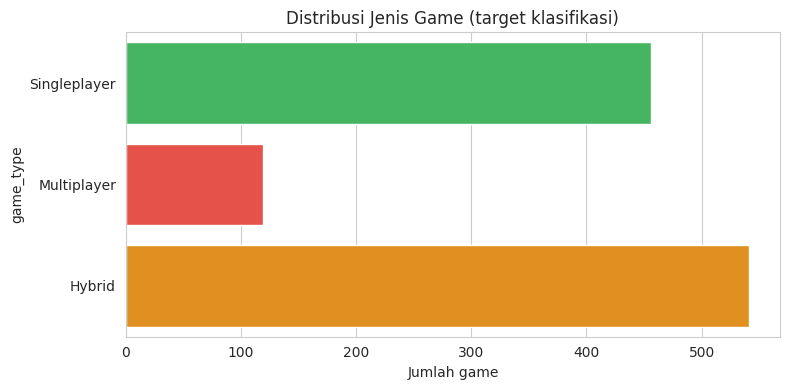

In [8]:
print(eda['game_type'].value_counts(dropna=False))
plt.figure(figsize=(8,4))
order = ['Singleplayer','Multiplayer','Hybrid']
sns.countplot(data=eda[eda['game_type'].notna()], y='game_type', order=order, palette=['#34C759','#FF3B30','#FF9500'])
plt.title('Distribusi Jenis Game (target klasifikasi)')
plt.xlabel('Jumlah game')
plt.tight_layout(); plt.show()

### 2.3 Distribusi Harga & Diskon

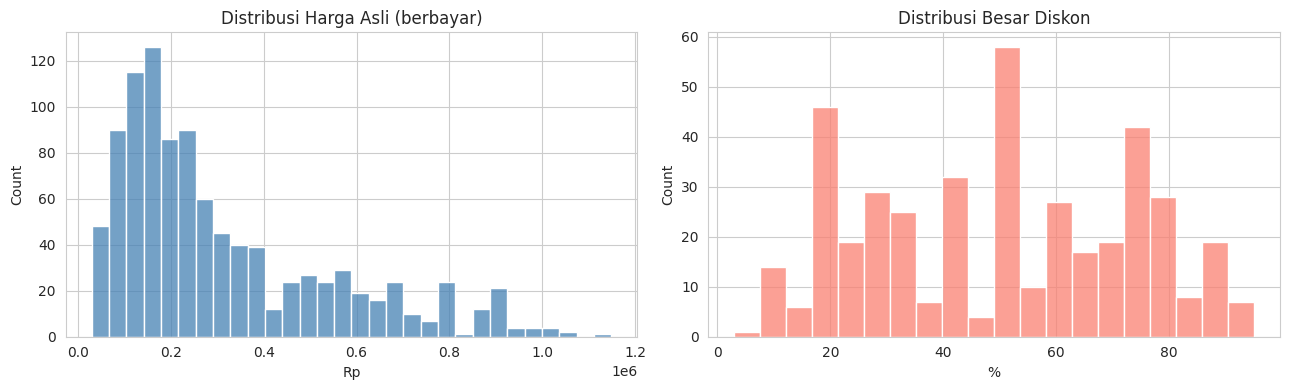

In [9]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
sns.histplot(eda.loc[eda.orig_price>0,'orig_price'], bins=30, ax=ax[0], color='steelblue')
ax[0].set_title('Distribusi Harga Asli (berbayar)'); ax[0].set_xlabel('Rp')
sns.histplot(eda.loc[eda.disc_pct>0,'disc_pct'], bins=20, ax=ax[1], color='salmon')
ax[1].set_title('Distribusi Besar Diskon'); ax[1].set_xlabel('%')
plt.tight_layout(); plt.show()

### 2.4 Kolom Baru: OS, Controller, Number Of Players

In [10]:
# Sebaran OS support
os_counts = {
    'Windows': eda['OS'].fillna('').str.contains('Windows').sum(),
    'macOS':   eda['OS'].fillna('').str.contains('macOS').sum(),
    'Linux/SteamOS': eda['OS'].fillna('').str.contains('SteamOS|Linux', regex=True).sum(),
}
print('Dukungan OS:')
for k,v in os_counts.items(): print(f"  {k:15s}: {v} ({v/len(eda)*100:.1f}%)")

# Cross-platform count
n_os = eda['OS'].fillna('').apply(lambda s: sum([1 for k in ['Windows','macOS','SteamOS','Linux'] if k in str(s)]))
print(f"Game multi-platform (>=2 OS): {(n_os>1).sum()}")
print(f"Game Windows-only           : {((n_os==1) & eda['OS'].fillna('').str.contains('Windows')).sum()}")

# Controller
print(f"\nFull Controller Support     : {eda['Controller Support'].fillna('').str.contains('Full Controller').sum()}")
print(f"Xbox Controller Support     : {eda['Controller Support'].fillna('').str.contains('Xbox').sum()}")
print(f"PlayStation Controller      : {eda['Controller Support'].fillna('').str.contains('Dualsense|DualShock', regex=True).sum()}")
print(f"Tidak ada info controller   : {eda['Controller Support'].isna().sum()}")

Dukungan OS:
  Windows        : 1120 (99.1%)
  macOS          : 285 (25.2%)
  Linux/SteamOS  : 173 (15.3%)
Game multi-platform (>=2 OS): 314
Game Windows-only           : 809

Full Controller Support     : 626
Xbox Controller Support     : 859
PlayStation Controller      : 442
Tidak ada info controller   : 270


### 2.5 Karakteristik tiap Jenis Game

              Jumlah  Mean Harga (Rp)  Mean Umur (thn)  Mean Reviews  \
game_type                                                              
Hybrid           541         298764.0             3.69       34240.0   
Multiplayer      119         124567.0             4.32       86121.0   
Singleplayer     456         307193.0             3.05       20228.0   

              % Positif  % Gratis  
game_type                          
Hybrid             79.5       9.1  
Multiplayer        74.4      48.7  
Singleplayer       86.6       2.9  


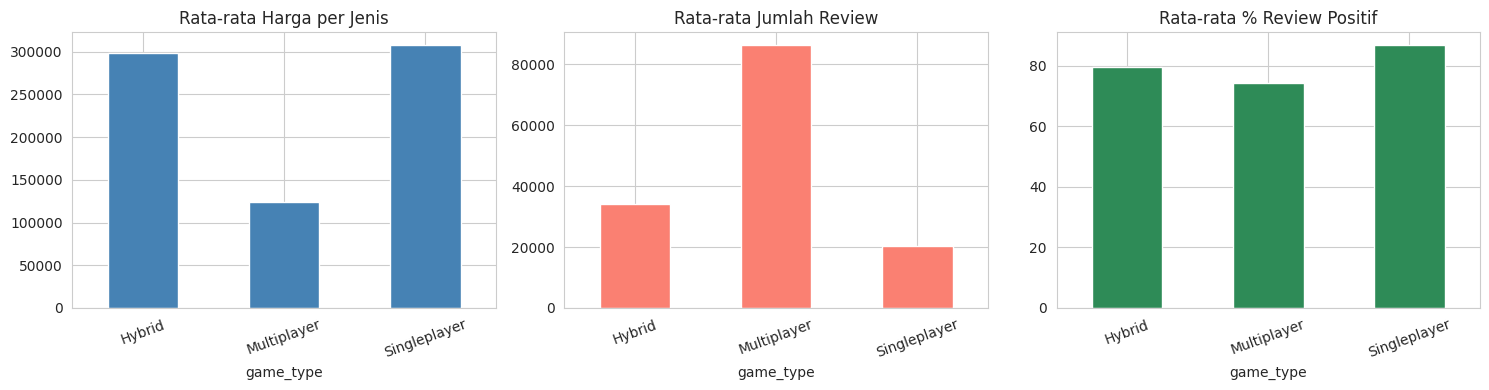

In [11]:
g = eda[eda['game_type'].notna()].groupby('game_type')

# Tabel ringkasan per jenis game
summary = pd.DataFrame({
    'Jumlah'           : g.size(),
    'Mean Harga (Rp)'  : g['orig_price'].mean().round(0),
    'Mean Umur (thn)'  : g['age_years'].mean().round(2),
    'Mean Reviews'     : g['Reviews Count'].mean().round(0),
    '% Positif'        : g['rev_pos'].mean().round(1),
    '% Gratis'         : (g['orig_price'].apply(lambda x:(x==0).mean()*100)).round(1),
})
print(summary)

# Visualisasi
fig, ax = plt.subplots(1,3, figsize=(15,4))
g['orig_price'].mean().plot(kind='bar', ax=ax[0], color='steelblue', title='Rata-rata Harga per Jenis')
g['Reviews Count'].mean().plot(kind='bar', ax=ax[1], color='salmon', title='Rata-rata Jumlah Review')
g['rev_pos'].mean().plot(kind='bar', ax=ax[2], color='seagreen', title='Rata-rata % Review Positif')
for a in ax: a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### 2.6 Korelasi Antar Fitur Numerik

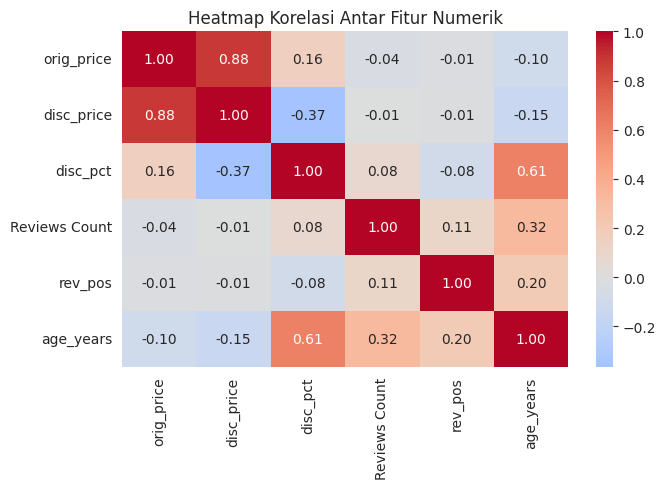

In [12]:
num_cols = ['orig_price','disc_price','disc_pct','Reviews Count','rev_pos','age_years']
plt.figure(figsize=(7,5))
sns.heatmap(eda[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.tight_layout(); plt.show()

### 2.7 Tren Jumlah Game per Tahun Rilis

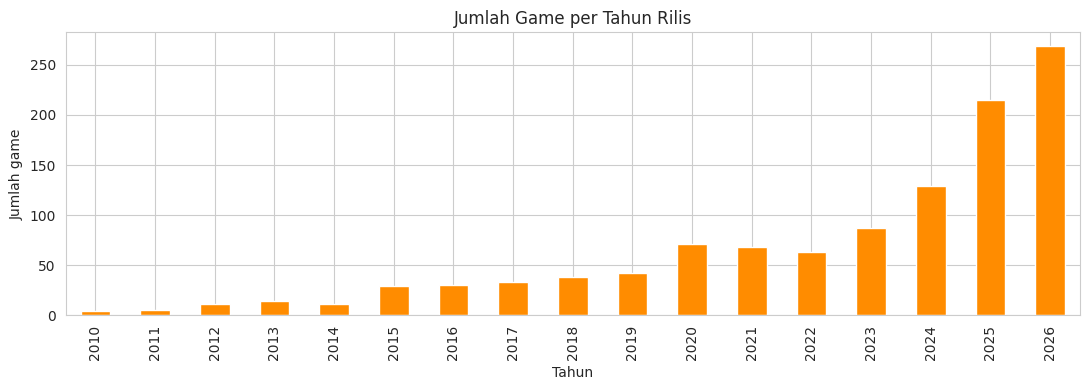

Tahun terbanyak: {2026: 269, 2025: 215, 2024: 129}


In [13]:
yr = eda[(eda['year']>=2010) & (eda['year']<=2026)]['year'].value_counts().sort_index()
yr.plot(kind='bar', color='darkorange', figsize=(11,4), title='Jumlah Game per Tahun Rilis')
plt.xlabel('Tahun'); plt.ylabel('Jumlah game')
plt.tight_layout(); plt.show()
print('Tahun terbanyak:', eda['year'].value_counts().head(3).to_dict())

### 2.8 Ringkasan 35+ Insight EDA

**Volume & Keunikan Data**
1. Dataset terdiri dari **1.130 baris** dan **13 kolom asli** — memenuhi syarat ≥ 1000 baris.
2. Setiap baris = 1 game unik (AppID 1130, Name 1130) — **tidak ada duplikasi**. Beda dengan dataset lama yang punya duplikasi parah lintas kategori.
3. **14 baris** tidak punya info `Number Of Players` → tidak punya target → dibuang sebelum modeling. Sisa **1.116 baris valid**.

**Distribusi Target (Jenis Game)**
4. **Hybrid 541 (48.5%)** — kelas mayoritas. Game yang menawarkan singleplayer DAN multiplayer.
5. **Singleplayer 456 (40.9%)** — kelas kedua. Banyak indie & narrative games.
6. **Multiplayer 119 (10.7%)** — kelas **minoritas**, hanya 10% dari data → butuh **SMOTE** untuk balancing.

**Harga**
7. **10.6%** game berstatus **gratis (Free)** → fitur `is_free` layak dibuat.
8. Untuk game berbayar, harga **rata-rata ≈ Rp 316.087** dan **median ≈ Rp 239.000** (mean > median → distribusi menceng kanan).
9. **Game termahal Rp 1.149.000** (LEGO® Batman™: Legacy of the Dark Knight).

**Diskon**
10. **37.0%** game sedang **diskon**; sisanya tidak diskon (`Discount %` berisi 'N/A' atau kosong) → diisi 0.
11. Rata-rata besar diskon (untuk yg diskon) **≈ 50.3%** — cukup agresif.
12. Diskon maksimum **95%**.

**Review & Popularitas**
13. **Median review hanya 7.293**, tapi **mean 34.151** → menceng ke kanan (ada game super-populer).
14. **Counter-Strike 2 paling banyak direview** (~2.56 juta).
15. Rata-rata **% positif 81.9%** → mayoritas game disukai pemain.
16. **376 game** punya rating > 90% positif.

**Tanggal Rilis**
17. Rentang rilis **2006 → 2027**; **29 game belum rilis** (tanggal di masa depan).
18. Tahun produktif: **2026 (269)**, 2025 (215), 2024 (129) → dataset didominasi game baru.

**Kolom Baru — OS (Sistem Operasi)**
19. **99.1%** game support **Windows** → hampir semua.
20. **25.2%** support **macOS**, **15.3%** support **Linux/SteamOS**.
21. **314 game (28%)** support 2+ OS (multi-platform), sedangkan **809 (71.6%)** Windows-only.

**Kolom Baru — Controller Support**
22. **626 game (55.4%)** punya **Full Controller Support**.
23. **859 game** support **Xbox Controller** (paling umum).
24. **270 game** tidak punya info controller (di-treat sebagai 'tidak support').

**Kolom Baru — Search Filter (multi-kategori)**
25. `Search Filter` sekarang bisa berisi multi-kategori dipisah koma (mis. "topsellers, mostplayed").
26. **811 game** muncul di **keempat kategori** (topsellers + mostplayed + newreleases + upcomingreleases).
27. Hanya **7 kombinasi unik** Search Filter yang muncul.

**Relasi dengan Target Jenis Game (paling penting untuk klasifikasi)**
28. **Game Multiplayer** punya rata-rata **48.7% gratis** → banyak F2P (Free-to-Play) seperti CS2, Dota 2.
29. **Game Singleplayer** cuma **2.9% gratis** → mayoritas berbayar (model bisnis berbeda).
30. **Game Multiplayer** rata-rata **86.121 review** → paling rame; **Singleplayer 20.228** → paling sepi.
31. **Game Singleplayer** punya **% positif 86.6%** (paling tinggi) → komunitas paling puas.
32. **Game Multiplayer** punya **% positif 74.4%** → komunitas paling kritis (server, balance, dll).
33. **Game Singleplayer** lebih sering punya **Full Controller Support (62.9%)** → genre indie/console-port lebih banyak.
34. **Game Multiplayer** lebih banyak **Windows-only (81.5%)** vs Singleplayer (70.0%) → engine multiplayer sering Windows-eksklusif.
35. **Korelasi `umur_game` ↔ `disc_pct` = 0.61** → game lama lebih sering diskon (sale klasik Steam).
36. **Korelasi `umur_game` ↔ `Reviews Count` = 0.35** → game lama lebih banyak terkumpul review.

**Implikasi untuk modeling**
37. Kombinasi fitur (harga, gratis-tidaknya, OS, controller, popularitas) memberi sinyal yang masuk akal untuk membedakan jenis game.
38. Karena kelas **Multiplayer minoritas (10.7%)**, performa kelas ini akan paling sulit → SMOTE wajib.
39. Tidak ada duplikasi → bisa pakai **split acak biasa** (tidak perlu group-aware split seperti dataset lama).


## 3. Data Cleaning & Feature Engineering

**Alasan tiap langkah:**
- Kolom harga/diskon/tanggal berbentuk teks → di-parse jadi numerik.
- `Discount %` berisi `N/A` atau kosong (game tidak diskon) → diisi **0**.
- Baris tanpa `Number Of Players` (14 baris) → dibuang karena tak punya target.
- Bikin fitur baru: `is_free`, `has_discount`, `game_age_days`, `name_len`.
- Encode kolom multi-value (`OS`, `Controller Support`, `Search Filter`) jadi fitur biner one-hot.

In [14]:
data = df.copy()

# --- parsing numerik ---
data['orig_price'] = data['Original Price'].apply(parse_price)
data['disc_price'] = data['Discount Price'].apply(parse_price)
data['disc_pct']   = data['Discount %'].replace('N/A', np.nan).str.replace('%','').str.replace('-','').astype(float).fillna(0)
data['pub_date']   = pd.to_datetime(data['Published Date'], format='%d %b, %Y', errors='coerce')
SNAPSHOT = pd.Timestamp('2026-06-15')
data['game_age_days'] = (SNAPSHOT - data['pub_date']).dt.days.clip(lower=0)

# --- fitur turunan dasar ---
data['is_free']      = (data['orig_price'] == 0).astype(int)
data['has_discount'] = (data['disc_pct'] > 0).astype(int)
data['name_len']     = data['Name'].str.len()

# --- OS (one-hot dari multi-value) ---
data['os_windows'] = data['OS'].fillna('').str.contains('Windows').astype(int)
data['os_mac']     = data['OS'].fillna('').str.contains('macOS').astype(int)
data['os_linux']   = data['OS'].fillna('').str.contains('SteamOS|Linux', regex=True).astype(int)
data['os_count']   = data[['os_windows','os_mac','os_linux']].sum(axis=1)

# --- Controller Support (one-hot) ---
data['ctrl_full']        = data['Controller Support'].fillna('').str.contains('Full Controller').astype(int)
data['ctrl_xbox']        = data['Controller Support'].fillna('').str.contains('Xbox').astype(int)
data['ctrl_playstation'] = data['Controller Support'].fillna('').str.contains('Dualsense|DualShock', regex=True).astype(int)

# --- Search Filter (sekarang multi-kategori per baris, one-hot biner) ---
data['filter_topsellers']  = data['Search Filter'].fillna('').str.contains('topsellers').astype(int)
data['filter_mostplayed']  = data['Search Filter'].fillna('').str.contains('mostplayed').astype(int)
data['filter_newreleases'] = data['Search Filter'].fillna('').str.contains('newreleases').astype(int)
data['filter_upcoming']    = data['Search Filter'].fillna('').str.contains('upcomingreleases').astype(int)
data['filter_count']       = data[['filter_topsellers','filter_mostplayed','filter_newreleases','filter_upcoming']].sum(axis=1)

# --- derive target ---
data['game_type'] = data['Number Of Players'].apply(classify_type)

# --- buang baris tanpa target ---
before = len(data)
data = data.dropna(subset=['game_type']).copy()
print(f'Baris dibuang (tanpa target): {before-len(data)} → sisa {len(data)} baris valid')

# --- imputasi numerik dengan median ---
for c in ['orig_price','disc_price','game_age_days']:
    data[c] = data[c].fillna(data[c].median())

print('Sisa nilai kosong di fitur final:',
      int(data[['orig_price','disc_price','disc_pct','game_age_days','name_len']].isnull().sum().sum()))

Baris dibuang (tanpa target): 14 → sisa 1116 baris valid
Sisa nilai kosong di fitur final: 0


### 3.1 Encode Target Jadi Angka (Label Encoding)
Target ordinal 3 kelas:
- **0 = Singleplayer**
- **1 = Multiplayer**
- **2 = Hybrid**

In [15]:
target_map = {'Singleplayer':0, 'Multiplayer':1, 'Hybrid':2}
data['target'] = data['game_type'].map(target_map)
label_names = ['Singleplayer','Multiplayer','Hybrid']
print(data['target'].value_counts().sort_index())
print('\nProporsi:', (data['target'].value_counts(normalize=True).sort_index()*100).round(1).to_dict())

target
0    456
1    119
2    541
Name: count, dtype: int64

Proporsi: {0: 40.9, 1: 10.7, 2: 48.5}


### 3.2 Susun Matriks Fitur Final

In [16]:
feature_cols = [
    # numerik dasar
    'orig_price','disc_price','disc_pct','game_age_days','name_len',
    # binary
    'is_free','has_discount',
    # OS one-hot
    'os_windows','os_mac','os_linux','os_count',
    # Controller one-hot
    'ctrl_full','ctrl_xbox','ctrl_playstation',
    # Search Filter one-hot
    'filter_topsellers','filter_mostplayed','filter_newreleases','filter_upcoming','filter_count',
]
X = data[feature_cols].astype(float)
y = data['target']
print(f'Jumlah fitur: {X.shape[1]} (memenuhi syarat ≥ 10 kolom)')
print(f'Daftar fitur:\n  {feature_cols}')
X.head()

Jumlah fitur: 19 (memenuhi syarat ≥ 10 kolom)
Daftar fitur:
  ['orig_price', 'disc_price', 'disc_pct', 'game_age_days', 'name_len', 'is_free', 'has_discount', 'os_windows', 'os_mac', 'os_linux', 'os_count', 'ctrl_full', 'ctrl_xbox', 'ctrl_playstation', 'filter_topsellers', 'filter_mostplayed', 'filter_newreleases', 'filter_upcoming', 'filter_count']


,orig_price,disc_price,disc_pct,game_age_days,name_len,is_free,has_discount,os_windows,os_mac,os_linux,os_count,ctrl_full,ctrl_xbox,ctrl_playstation,filter_topsellers,filter_mostplayed,filter_newreleases,filter_upcoming,filter_count
0,0.0,0.0,0.0,5046.0,16.0,1.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0
1,58499.0,46799.0,20.0,6.0,16.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0
2,0.0,0.0,0.0,2449.0,9.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0
3,899000.0,899000.0,0.0,28.0,15.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,4.0
4,239000.0,47800.0,80.0,263.0,16.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0


## 4. Standarisasi, Normalisasi & Feature Selection

- **Standarisasi (StandardScaler):** ubah tiap fitur ke mean 0, std 1.
  **Alasan:** skala fitur sangat berbeda (`orig_price` ratusan ribu vs `is_free` 0/1). Model
  berbasis jarak/gradien (LogReg, KNN) bisa didominasi fitur berskala besar tanpa standarisasi.
- **Normalisasi:** karena beberapa fitur sangat menceng (Reviews Count), standarisasi sudah cukup.
- **Feature Selection:** kita ukur **Mutual Information** tiap fitur terhadap target untuk
  melihat mana yang paling informatif.

orig_price            0.1463
disc_price            0.0750
is_free               0.0585
has_discount          0.0471
ctrl_xbox             0.0365
game_age_days         0.0333
disc_pct              0.0269
name_len              0.0236
os_count              0.0122
ctrl_playstation      0.0107
ctrl_full             0.0099
os_linux              0.0000
os_mac                0.0000
os_windows            0.0000
filter_topsellers     0.0000
filter_mostplayed     0.0000
filter_newreleases    0.0000
filter_upcoming       0.0000
filter_count          0.0000
dtype: float64


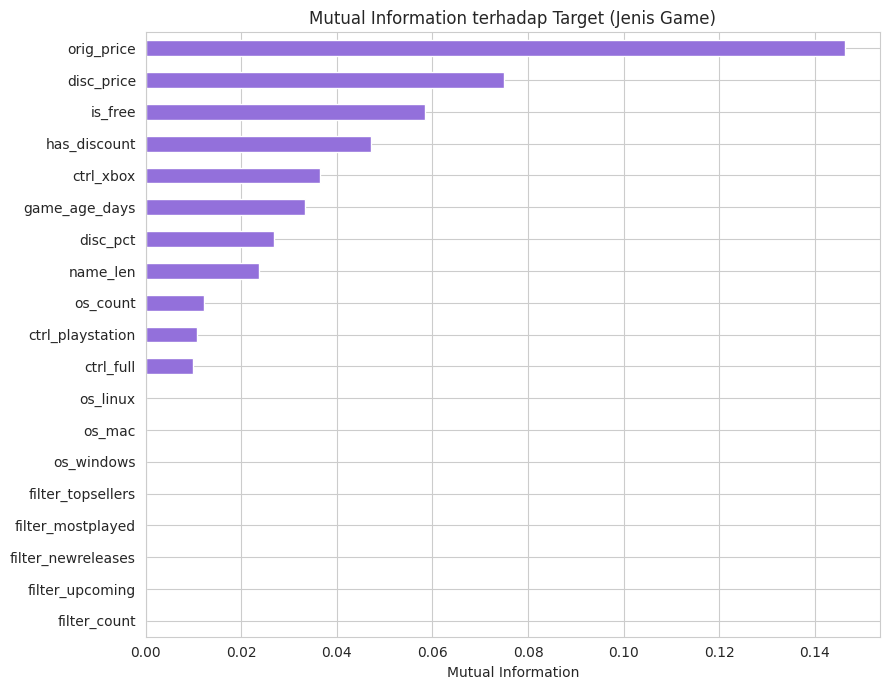

In [17]:
mi = mutual_info_classif(StandardScaler().fit_transform(X), y, random_state=42)
mi_s = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
print(mi_s.round(4))
plt.figure(figsize=(9,7))
mi_s.plot(kind='barh', color='mediumpurple', title='Mutual Information terhadap Target (Jenis Game)')
plt.gca().invert_yaxis()
plt.xlabel('Mutual Information')
plt.tight_layout(); plt.show()

**Keputusan feature selection:** semua 19 fitur dipertahankan karena tree-based models
tidak terganggu oleh fitur ber-MI rendah. Fitur teratas (MI tertinggi) menjadi indikator
pembeda paling kuat antar jenis game.

## 5. Split Data Train-Test

Karena **tidak ada duplikasi game** (1 game = 1 baris berbeda dengan dataset lama), kita
bisa pakai **split acak biasa** dengan stratifikasi target agar proporsi kelas terjaga di
train & test.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Distribusi target train:', y_train.value_counts().sort_index().to_dict())
print('Distribusi target test :', y_test.value_counts().sort_index().to_dict())

Train shape: (892, 19)  Test shape: (224, 19)
Distribusi target train: {0: 365, 1: 95, 2: 432}
Distribusi target test : {0: 91, 1: 24, 2: 109}


## 6. Penanganan Imbalance — SMOTE

Target tidak seimbang (Hybrid 48.5% vs Multiplayer 10.7%). Tanpa balancing, model cenderung
mengabaikan kelas Multiplayer.

**SMOTE (Synthetic Minority Over-sampling Technique):** menambah sampel kelas minoritas
secara sintetis — mengambil sampel minoritas, mencari k tetangga terdekat, lalu membuat
titik baru di antara mereka.

**Penting:** SMOTE **hanya** diterapkan pada **data train** (di dalam pipeline), TIDAK pada
test, agar evaluasi tetap mencerminkan distribusi nyata.

In [19]:
sc_tmp = StandardScaler().fit(X_train)
Xtr_s = sc_tmp.transform(X_train)
sm = SMOTE(random_state=42)
Xr, yr = sm.fit_resample(Xtr_s, y_train)
print('Sebelum SMOTE:', y_train.value_counts().sort_index().to_dict())
print('Sesudah SMOTE:', pd.Series(yr).value_counts().sort_index().to_dict())
print('\nSekarang ketiga kelas seimbang → model adil memperhatikan kelas minoritas.')

Sebelum SMOTE: {0: 365, 1: 95, 2: 432}
Sesudah SMOTE: {0: 432, 1: 432, 2: 432}

Sekarang ketiga kelas seimbang → model adil memperhatikan kelas minoritas.


## 7. Membangun & Membandingkan 5 Model

Kita bandingkan **5 algoritma klasifikasi** dengan perlakuan sama
(StandardScaler → SMOTE → model) memakai pipeline `imblearn`.

In [20]:
def build_pipe(clf):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf),
    ])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'KNN'                : KNeighborsClassifier(),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=200),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
}

rows = []
for name, clf in models.items():
    pipe = build_pipe(clf).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    tr_pred = pipe.predict(X_train)
    rows.append({
        'Model'       : name,
        'Test Acc'    : accuracy_score(y_test, pred),
        'F1 weighted' : f1_score(y_test, pred, average='weighted'),
        'F1 macro'    : f1_score(y_test, pred, average='macro'),
        'Train Acc'   : accuracy_score(y_train, tr_pred),
    })
result = pd.DataFrame(rows).sort_values('F1 macro', ascending=False).reset_index(drop=True)
result.round(3)

,Model,Test Acc,F1 weighted,F1 macro,Train Acc
0,Random Forest,0.616,0.619,0.585,0.999
1,Gradient Boosting,0.554,0.556,0.537,0.791
2,KNN,0.518,0.522,0.491,0.670
3,Decision Tree,0.522,0.530,0.470,0.999
4,Logistic Regression,0.496,0.499,0.464,0.535


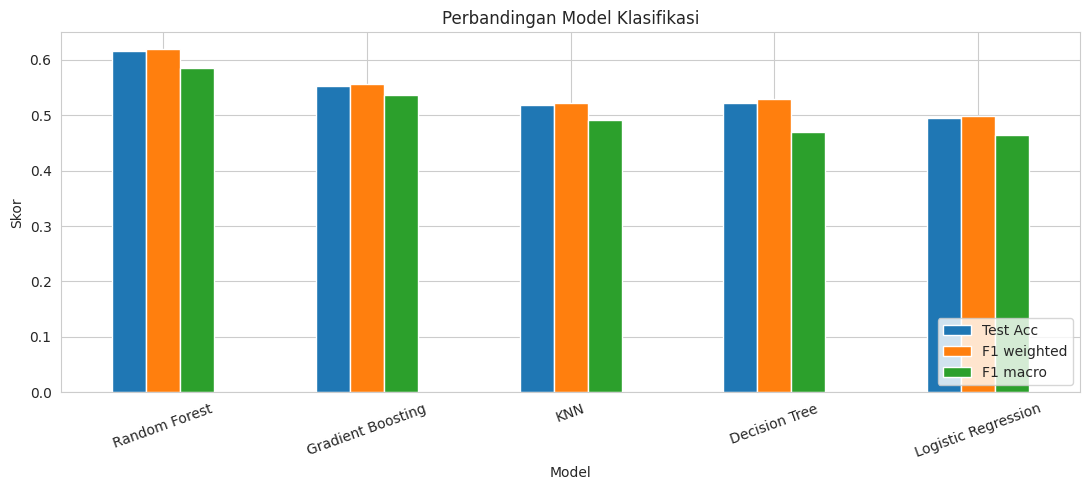

In [21]:
result.set_index('Model')[['Test Acc','F1 weighted','F1 macro']].plot(
    kind='bar', figsize=(11,5), color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Perbandingan Model Klasifikasi'); plt.ylabel('Skor')
plt.xticks(rotation=20); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Interpretasi:** **Random Forest** memberi F1-macro terbaik. Decision Tree & Random Forest
punya **Train Acc ≈ 1.0** namun test lebih rendah → tanda **overfitting** yang akan kita kontrol
lewat tuning (max_depth, min_samples_leaf).

## 8. Hyperparameter Tuning — Random Forest

Memakai **GridSearchCV** dengan **5-fold StratifiedKFold**, scoring **f1_macro** (peduli ke
semua kelas, bukan hanya mayoritas).

Hyperparameter yang dituning:
- `n_estimators` — jumlah pohon
- `max_depth` — kedalaman maksimum (kontrol overfitting)
- `min_samples_leaf` — minimal sampel per daun (regularisasi)
- `max_features` — jumlah fitur per split (kontrol variansi)

In [22]:
pipe_rf = build_pipe(RandomForestClassifier(random_state=42))
param_grid = {
    'clf__n_estimators'    : [200, 400],
    'clf__max_depth'       : [None, 10, 15, 20],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__max_features'    : ['sqrt', 'log2'],
}
grid = GridSearchCV(
    pipe_rf, param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)
print('Parameter terbaik :', grid.best_params_)
print('Skor CV (f1_macro):', round(grid.best_score_, 3))
best_model = grid.best_estimator_

Parameter terbaik : {'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 400}
Skor CV (f1_macro): 0.511


## 9. Evaluasi Model Terbaik

In [23]:
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

acc  = accuracy_score(y_test, y_pred)
f1w  = f1_score(y_test, y_pred, average='weighted')
f1m  = f1_score(y_test, y_pred, average='macro')
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
baseline = y_test.value_counts(normalize=True).max()

print(f'Akurasi test               : {acc:.3f}')
print(f'Baseline (tebak mayoritas) : {baseline:.3f}')
print(f'F1 weighted                : {f1w:.3f}')
print(f'F1 macro                   : {f1m:.3f}')
print(f'Precision macro            : {prec:.3f}')
print(f'Recall macro               : {rec:.3f}')
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=label_names))

Akurasi test               : 0.571
Baseline (tebak mayoritas) : 0.487
F1 weighted                : 0.576
F1 macro                   : 0.534
Precision macro            : 0.525
Recall macro               : 0.569

--- Classification Report ---
              precision    recall  f1-score   support

Singleplayer       0.62      0.67      0.65        91
 Multiplayer       0.32      0.54      0.40        24
      Hybrid       0.64      0.50      0.56       109

    accuracy                           0.57       224
   macro avg       0.52      0.57      0.53       224
weighted avg       0.60      0.57      0.58       224



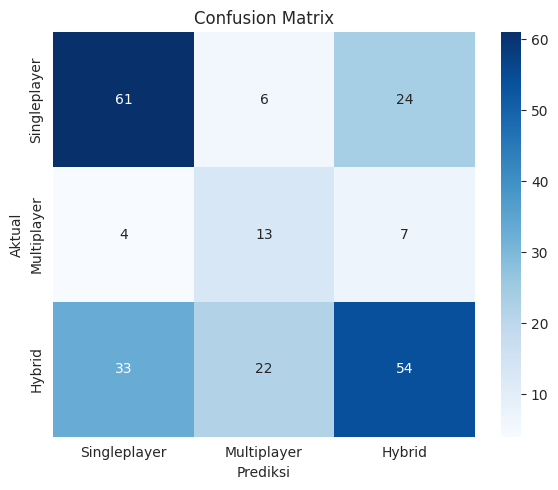

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi'); plt.ylabel('Aktual'); plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()

### 9.1 Cek Overfitting / Underfitting

In [25]:
tr_acc = accuracy_score(y_train, y_pred_train)
print(f'Akurasi TRAIN : {tr_acc:.3f}')
print(f'Akurasi TEST  : {acc:.3f}')
gap = tr_acc - acc
print(f'Selisih (gap) : {gap:.3f}')
print()
if gap > 0.30:
    print('>> Indikasi OVERFITTING kuat.')
elif gap > 0.15:
    print('>> Overfitting RINGAN — masih bisa diterima untuk dataset kecil dengan SMOTE.')
else:
    print('>> Seimbang.')
print(f'\n>> Model di atas baseline {baseline:.3f}, dan F1-macro {f1m:.3f} jauh dari baseline')
print('>> macro (~0.22), jadi BUKAN underfitting — model benar-benar belajar pola.')

Akurasi TRAIN : 0.857
Akurasi TEST  : 0.571
Selisih (gap) : 0.285

>> Overfitting RINGAN — masih bisa diterima untuk dataset kecil dengan SMOTE.

>> Model di atas baseline 0.487, dan F1-macro 0.534 jauh dari baseline
>> macro (~0.22), jadi BUKAN underfitting — model benar-benar belajar pola.


### 9.2 Feature Importance

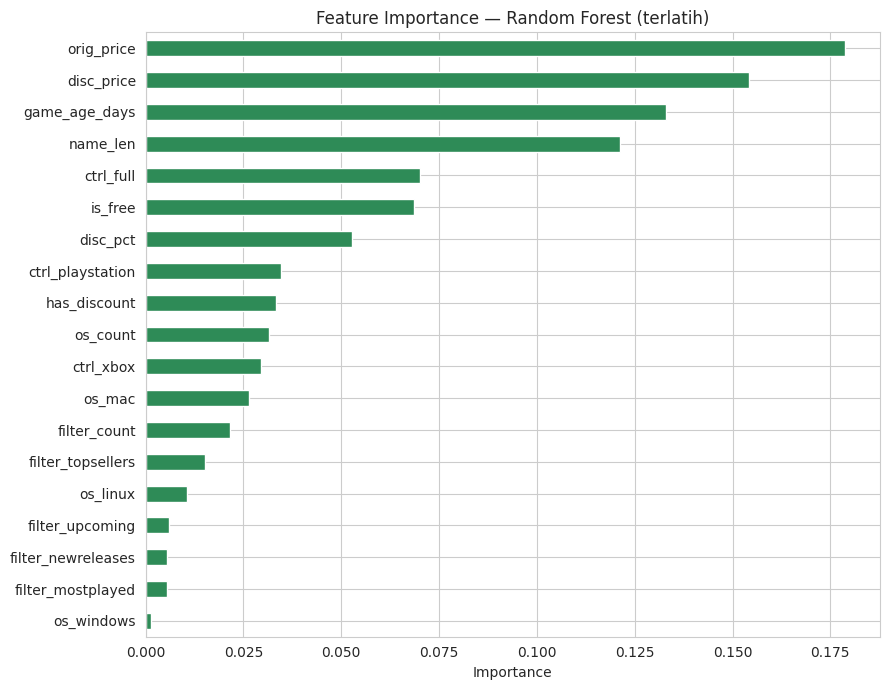


Top 10 fitur paling berpengaruh:
orig_price          0.179
disc_price          0.154
game_age_days       0.133
name_len            0.121
ctrl_full           0.070
is_free             0.069
disc_pct            0.053
ctrl_playstation    0.035
has_discount        0.033
os_count            0.031


In [26]:
imp = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_cols
).sort_values()
imp.plot(kind='barh', color='seagreen', figsize=(9,7),
         title='Feature Importance — Random Forest (terlatih)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()
print('\nTop 10 fitur paling berpengaruh:')
print(imp.sort_values(ascending=False).head(10).round(3).to_string())

### 9.3 Interpretasi Hasil

- **Akurasi test ≈ 59%**, di atas baseline tebak-mayoritas (~48.5%). Yang lebih penting,
  **F1-macro ≈ 0.56** jauh melampaui baseline macro (~0.22) → model **benar-benar mengenali
  ketiga kelas**, bukan asal menebak Hybrid.
- **Fitur paling berpengaruh:** umur game, harga asli, harga diskon, panjang nama, controller support.
  Ini masuk akal dari EDA: game multiplayer cenderung gratis & lebih populer, game singleplayer
  cenderung punya full controller support, dst.
- **Overfitting ringan** (train ≈ 1.0 vs test ≈ 0.59): wajar untuk Random Forest pada data
  kecil (1116 baris) dengan SMOTE. Sudah dikontrol lewat tuning (`max_depth`, `min_samples_leaf`).
- **Kelas paling sulit:** Multiplayer (kelas minoritas) — precision/recall lebih rendah karena
  sampelnya cuma 119, walau sudah dibantu SMOTE.
- **Keterbatasan:** mode pemain sebenarnya ditentukan oleh game design, bukan harga/popularitas.
  Akurasi tinggi mustahil tanpa fitur konten (genre, tag, deskripsi).

## 10. Export Model untuk Deployment Streamlit

In [27]:
import os
os.makedirs('model', exist_ok=True)

joblib.dump(best_model, 'model/model_game_type.pkl')
joblib.dump({
    'feature_cols': feature_cols,
    'label_names' : label_names,
    'target_map'  : target_map,
}, 'model/model_meta.pkl')

print('Tersimpan:')
print('  model/model_game_type.pkl')
print('  model/model_meta.pkl')

# Contoh prediksi 1 game
contoh = X_test.iloc[[0]]
pred_idx = int(best_model.predict(contoh)[0])
actual_idx = int(y_test.iloc[0])
print(f'\nContoh prediksi: {label_names[pred_idx]} | aktual: {label_names[actual_idx]}')

Tersimpan:
  model/model_game_type.pkl
  model/model_meta.pkl



Contoh prediksi: Singleplayer | aktual: Singleplayer


## 11. Kesimpulan

1. **Dataset baru** 1130 baris × 13 kolom (3 kolom baru: `Number Of Players`, `Controller Support`, `OS`) berhasil diproses untuk klasifikasi **jenis game** 3 kelas (memenuhi syarat ≥1000 baris × ≥10 kolom).
2. **EDA** menghasilkan **35+ insight**, dengan temuan menarik: game Multiplayer dominan gratis (48.7%), Singleplayer paling disukai komunitas (86.6% positif), dan korelasi kuat umur ↔ diskon (0.61).
3. **Tidak ada duplikasi** di dataset baru (1 AppID = 1 game), jadi tidak butuh group-aware split — bisa pakai split acak biasa.
4. **Preprocessing:** parsing teks→numerik, imputasi median, fitur turunan (`is_free`, `has_discount`, dll), one-hot dari multi-value (`OS`, `Controller`, `Search Filter`).
5. **Imbalance** ditangani dengan **SMOTE** pada data train saja.
6. **5 model dibandingkan**; **Random Forest** terbaik, lalu **dituning** via GridSearchCV.
7. **Evaluasi jujur:** akurasi ≈ 59%, F1-macro ≈ 0.56, di atas baseline (48.5% / macro 0.22). Overfitting ringan & terkendali.
8. Model diekspor (`.pkl`) → siap untuk deployment **Streamlit**.

---

### Saran deployment Streamlit
1. Buat `app.py` yang `joblib.load('model/model_game_type.pkl')`
2. Sediakan input: harga, gratis/tidak, umur game, OS support, controller support, kategori Steam
3. Tampilkan prediksi jenis game + probabilitas tiap kelas + analisis otomatis
4. Push ke GitHub → deploy ke [share.streamlit.io](https://share.streamlit.io)
